# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?

**For the purposes of this lab you MUST use the model building techniques we covered in class.  Failure to do so will automatically result in a 20 point deduction.  I really want you to think about what you are doing and not just paste what you get from ChatGPT (which will often NOT do the correct thing by default).**



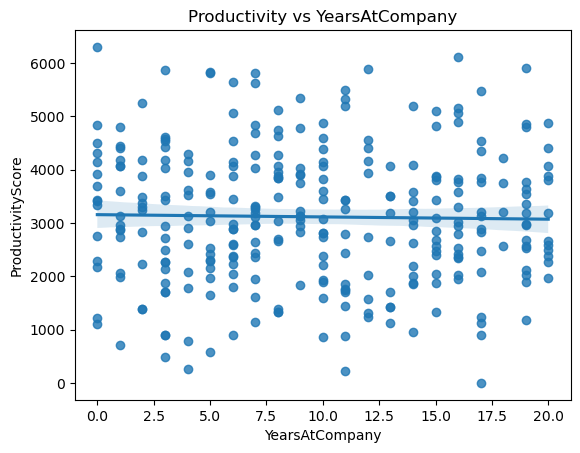

YearsAtCompany R-squared: 0.0004


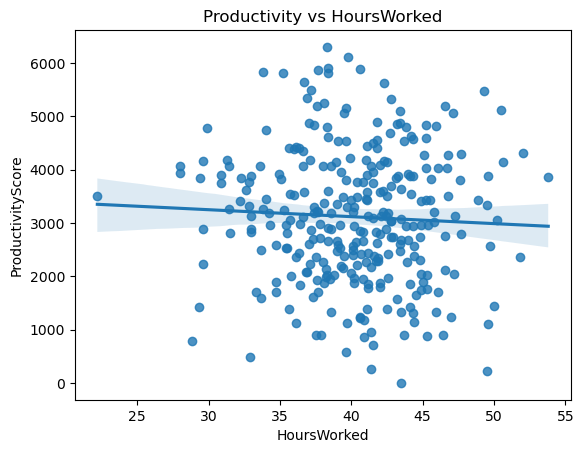

HoursWorked R-squared: 0.0026


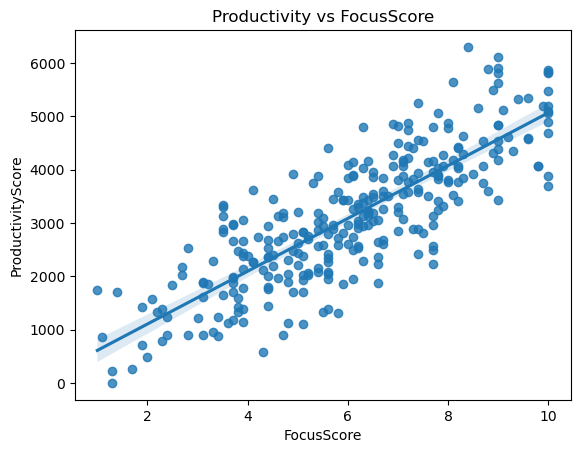

FocusScore R-squared: 0.6777


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

df = pd.read_csv('Employee_productivity.csv')

# Helper function to get R-squared using statsmodels OLS
def get_model_stats(feature):
    X = sm.add_constant(df[feature]) # Adding the constant as shown in class
    y = df['ProductivityScore']
    model = sm.OLS(y, X).fit()
    return model.rsquared

# 1. Visualize and Calculate
features = ['YearsAtCompany', 'HoursWorked', 'FocusScore']
for f in features:
    sns.regplot(x=f, y='ProductivityScore', data=df)
    plt.title(f'Productivity vs {f}')
    plt.show()
    print(f"{f} R-squared: {get_model_stats(f):.4f}")

In [9]:
# Create the features as we did before
df['Is_Remote'] = df['DeskLocation'].map({'Remote': 1, 'Open Plan': 0, 'Private Office': 0})
df['Is_OpenPlan'] = df['DeskLocation'].map({'Remote': 0, 'Open Plan': 1, 'Private Office': 0})
df['Is_HR'] = df['Department'].map({'HR': 1, 'Engineering': 0, 'Sales': 0})
df['Is_Sales'] = df['Department'].map({'HR': 0, 'Engineering': 0, 'Sales': 1})

# NEW STEP: Drop any rows that now contain NaN values
df_clean = df.dropna(subset=['FocusScore', 'HoursWorked', 'TeamMeetingsPerWeek', 
                             'Is_Remote', 'Is_OpenPlan', 'Is_HR', 'Is_Sales', 
                             'ProductivityScore'])

# Use df_clean for the model
X = sm.add_constant(df_clean[['FocusScore', 'HoursWorked', 'TeamMeetingsPerWeek', 
                              'Is_Remote', 'Is_OpenPlan', 'Is_HR', 'Is_Sales']])
y = df_clean['ProductivityScore']
final_model = sm.OLS(y, X).fit()
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:      ProductivityScore   R-squared:                       0.680
Model:                            OLS   Adj. R-squared:                  0.670
Method:                 Least Squares   F-statistic:                     66.79
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           5.61e-51
Time:                        13:32:48   Log-Likelihood:                -1812.6
No. Observations:                 228   AIC:                             3641.
Df Residuals:                     220   BIC:                             3669.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                -353.4574    

# Summary of Factors
The data reveals that FocusScore is the primary driver of productivity at this company.

Interestingly, contrary to management's worries and employee complaints, Years at the Company and Hours Worked have almost no statistical impact on actual output. While Team Meetings do show a relationship, the coefficient is positive (63.09), suggesting that structured coordination might actually be helping rather than hurting, despite the complaints.

# Recommendations
1. Protect Focus Time: Since FocusScore is the only major predictor of success (P < 0.05), the company should prioritize "deep work" blocks.
2. Environment Optimization: Although not quite significant at the 5% level, the Open Plan coefficient (183.4) is positive in this specific model, but the low FocusScores in the scatterplots suggest that if an office layout hurts focus, it hurts productivity.
3. Ignore the Tenure Debate: Managers should stop worrying about "lazy" senior staff or "unfocused" new hires. The data shows tenure is irrelevant to productivity; focus is what matters.